In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..", "Code")))
import os
import json

import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

from tools_.preprocess_data import Preprocess_Dataset
from scripts.visualization.utils.renderizer import EGMRenderer_BSP

from tools_.load_dataset import LoadDataset_BSPS
from scripts.visualization.utils.bsp_3d_plotter import BSP_3D_PLOTTER
from scripts.visualization.utils.egm_3d_plotter import EGM_3D_PLOTTER
from scripts.visualization.utils.corr_3d_plotter import CORRELATION_3D_PLOTTER

from scripts.Tikhonov.compute_tik import TikhonovReconstruction
from scripts.evaluate_function import *
from tools_.tools import corr_pearson_cols
from tools_.tools_inference import *


2025-01-20 22:37:32.624069: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-20 22:37:32.650753: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-20 22:37:32.650773: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-20 22:37:32.651852: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-20 22:37:32.656988: I tensorflow/core/platform/cpu_feature_guar

Error loading DataConfig: [Errno 2] No such file or directory: 'scripts/src/training/hyperparams/hyperparams.json'


In [2]:
#INDEX 

#I) ESPACIAL
#1. Voltage maps
#2. Correlation maps
#3. RMSE maps
#4. DF Maps

#II) TEMPORAL --> Notebook
# BSPM, EGM, EGM rec mismo plot
# Espectros


torso_num=2
model_path=f"/home/pdi/miriamgf/tesis/Autoencoders/Labeled_torsos/Torso{torso_num}_mod.mat"
model_name = ["Simulation_01_200316_001_  3"]

# Cargar datos
#model_path = "/home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/experiments/experiments_VAE/OMAMI_weighted/reconstructions_by_model_OMAMI_weighted.mat"

geom_path_CF = "/home/pdi/miriamgf/tesis/Autoencoders/geometries/Atria_geom/Modelos_computacionales_Carlos_Fambuena/Atria.mat"
geom_path_edgar= "/home/pdi/miriamgf/tesis/Autoencoders/geometries/Atria_geom/Modelos_Edgar/Atria.mat"
output_directory = "/home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/renderized_heart/OMAMI"
os.makedirs(output_directory, exist_ok=True)
data_dir = "/home/profes/miriamgf/tesis/Autoencoders/Data/"
torsos_dir = "/home/profes/miriamgf/tesis/Autoencoders/Labeled_torsos/"

experiment_dir="/home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/experiments/experiments_VAE/OMAMI_repeated/"
model_path=experiment_dir+"reconstructions_by_model_OMAMI_repeated.mat"
weights_path = experiment_dir + "model_weights.h5"
params_path=experiment_dir+'hyperparams.json'

In [3]:
def normalize_array(array, high=1, low=-1, axis_n=0):
    mins = np.min(array, axis=axis_n)
    maxs = np.max(array, axis=axis_n)
    rng = maxs - mins
    if axis_n == 1:
        array = array.T
    norm_array = high - (((high - low) * (maxs - array)) / rng)
    if axis_n == 1:
        norm_array = norm_array.T
    return norm_array

def downsampling(array, fs_sub):
    downsampling_factor = int(500 / fs_sub)
    array_sub = array[::downsampling_factor]
    return array_sub

68 Models
Loading model Simulation_01_200316_001_  3 ......


2025-01-20 22:37:42.215285: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Plotting BSPM


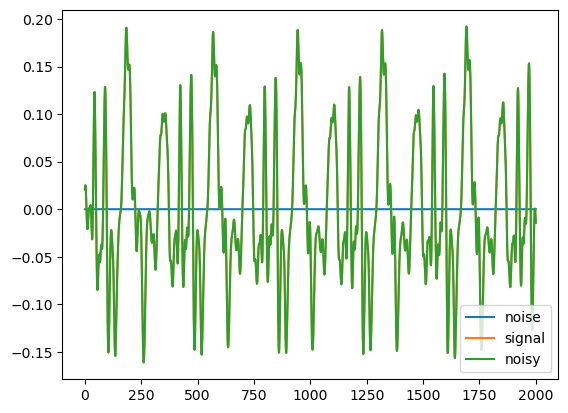

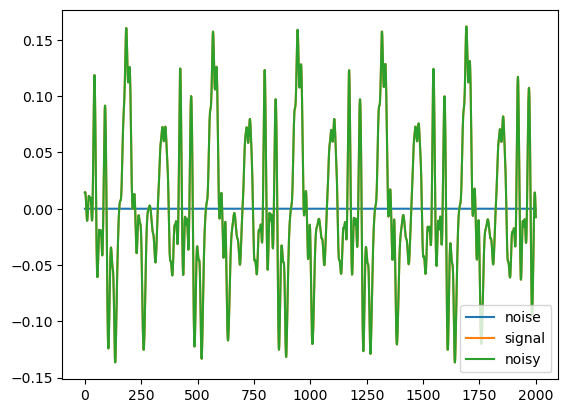

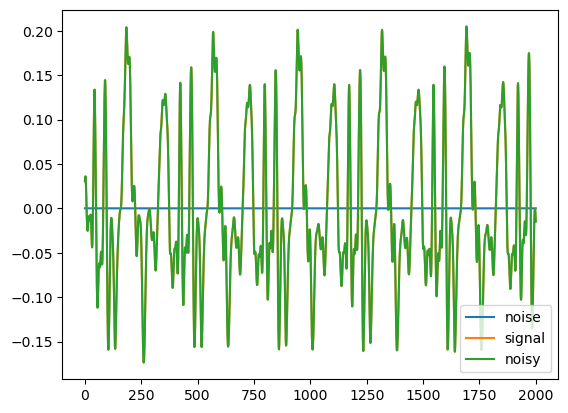

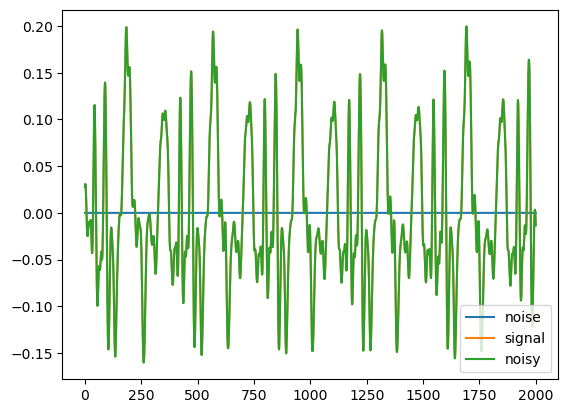

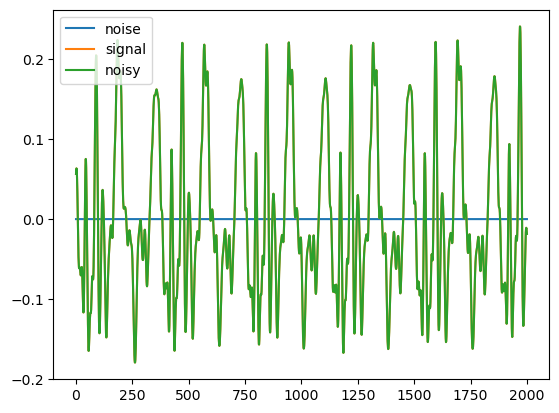

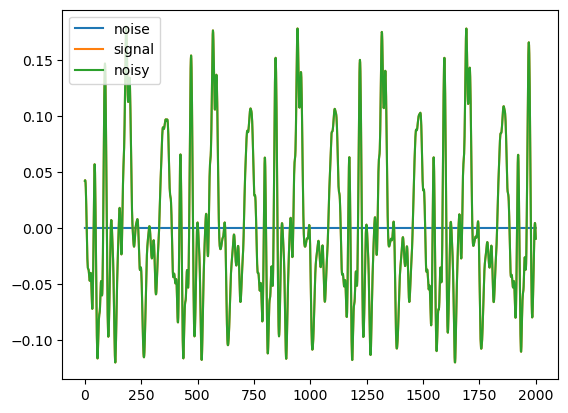

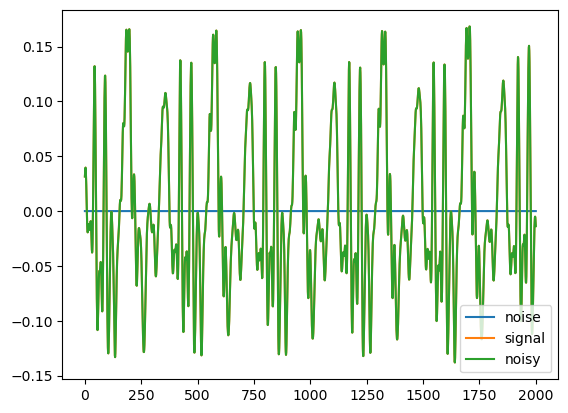

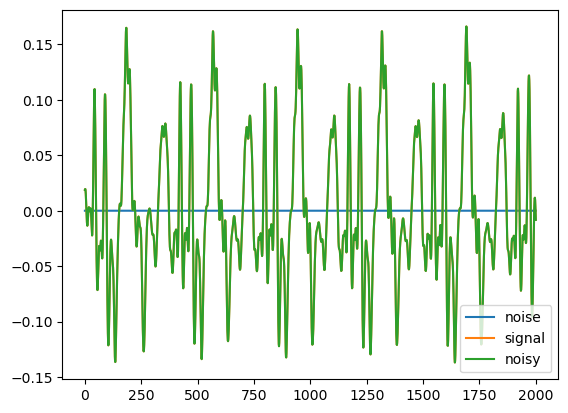

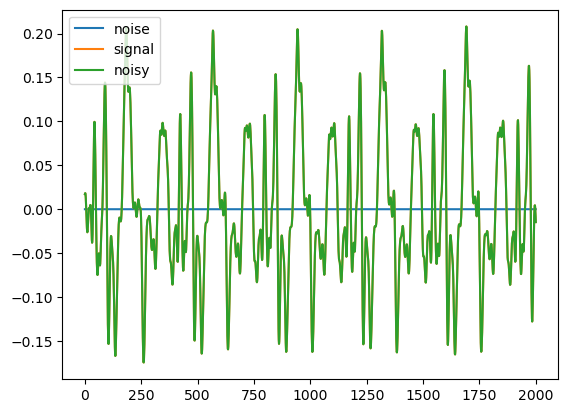

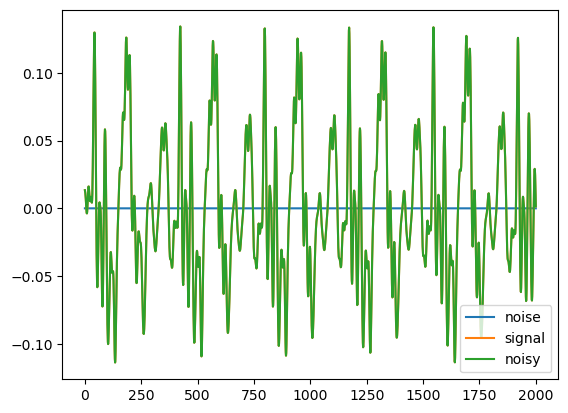

In [ ]:

#Load params dictionary
with open(experiment_dir+"hyperparams.json") as file:
    params = json.load(file)  # Load the JSON data into a dictionary
    
# Cargar datos del modelo y la geometría
all_torsos_names = []
for subdir, dirs, files in os.walk(torsos_dir):
    for file in files:
        if file.endswith(".mat"):
            all_torsos_names.append(file)

#Load geometry

SNR_em_noise = None
SNR_white_noise = 100
patches_oclussion = "PT"
experiment_number = 0
unfold_code = 1


# Load test model
(
    X_1channel,
    Y,
    Y_model,
    egm_tensor,
    length_list,
    AF_models,
    all_model_names,
    transfer_matrices,
    y_list
) = LoadDataset_BSPS(
    params,
    directory=data_dir,
    data_type="1channelTensor",
    n_classes=params["n_classes"],
    downsampling=False,
    fs=params["fs"],
    norm=False,
    SR=True,
    n_batch=params["batch_size"],
    sinusoid=False,
    SNR_em_noise=SNR_em_noise,
    SNR_white_noise=SNR_white_noise,
    patches_oclussion=patches_oclussion,
    unfold_code=unfold_code,
    inference=False,
    select_model = model_name
)()





In [5]:
#Unpack
torso_name = f"Torso{torso_num}_mod.mat"
torso_index = all_torsos_names.index(torso_name)
bspm_signal = y_list[torso_index]['y']
transfer_matrix= transfer_matrices[torso_index][0]

#Select only specified torso signals
egm_single=np.split(egm_tensor, 10)[torso_index]
X_1channel_single=np.split(X_1channel, 10)[torso_index]
AF_models_single=np.split(np.array(AF_models), 10)[torso_index]
Y_model_single=np.split(np.array(Y_model), 10)[torso_index]



In [ ]:
#Preprocess bspm (normalization)
bspm_signal_norm = normalize_array(bspm_signal, high=1, low=-1, axis_n=0) 

#Compute Tikhonov
tik_rec=TikhonovReconstruction(bspm_signal_norm, transfer_matrix, order=0)()



Computing Tikhonov


/home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/scripts/Tikhonov/forward_inverse_problem.py:337: RuntimeWarning: invalid value encountered in divide
  curve = curve_term1 / curve_term2


In [7]:
tik_rec = tik_rec[:, :-1]
tik_rec= tik_rec.T
tik_rec=downsampling(tik_rec, 200)


(1000, 2048) (3042, 2001)


In [11]:
#DL Prediction
print("Computing inference")
n_batch=400
dic_vars={}


# Preprocess data
(
  X_1channel, egm_tensor, AF_models, Y_model
) = Preprocess_Dataset(
    params,
    X_1channel_single,
    egm_single,
    list(AF_models_single),
    Y_model,
    dic_vars,
    Y,
    all_model_names,
    transfer_matrices,
    experiment_dir,
    norm_egm=True,
    inference=True
)()

#batch gen
rows = X_1channel.shape[0]
divisible_rows = (rows // n_batch) * n_batch

X_1channel = X_1channel[:divisible_rows]
egm_tensor=egm_tensor[:divisible_rows]
tik_trunc=tik_rec[:divisible_rows]

bsps_batches = reshape(
                X_1channel,
                (
                    int(len(X_1channel) / n_batch),
                    n_batch,
                    X_1channel.shape[1],
                    X_1channel.shape[2],
                    1,
                ),
            )
egm_batches = reshape(
                egm_tensor,
                (
                    int(len(egm_tensor) / n_batch),
                    n_batch,
                    egm_tensor.shape[1],
                    1,
                ),
            )
tik_batches = reshape(
                tik_trunc,
                (
                    int(len(tik_trunc) / n_batch),
                    n_batch,
                    tik_trunc.shape[1],
                    1,
                ),
            )
# Inference
weights_path="/home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/experiments/experiments_VAE/OMAMI_repeated/model_weights.h5"
model = load_model(weights_path)

prediction = model.predict(
    bsps_batches, batch_size=1
)  # x_test=[#batches, batch_size, 12, 32, 1]
prediction = prediction[1]
prediction_flat = prediction.reshape(
    (prediction.shape[0] * prediction.shape[1], prediction.shape[2])
)
egm_flat = egm_batches.reshape(
    (prediction.shape[0] * prediction.shape[1], prediction.shape[2])
)
bsp_flat = bsps_batches.reshape(
    (bsps_batches.shape[0] * bsps_batches.shape[1], bsps_batches.shape[2]* bsps_batches.shape[3])
)
tik_flat = tik_batches.reshape(
    (tik_batches.shape[0] * tik_batches.shape[1], tik_batches.shape[2])
)



Computing inference
2/2 [==============================] - 0s 33ms/step


In [13]:
#Preprocess before plotting

prediction_norm = normalize_by_models(prediction_flat, Y_model)
egm_norm = normalize_by_models(egm_flat, Y_model)
X_1channel_norm = normalize_by_models(bsp_flat, Y_model)
tik_rec_norm= normalize_by_models(tik_rec, Y_model)

prediction_centered= prediction_norm-np.mean(prediction_norm)
egm_centered=egm_flat-np.mean(egm_flat)
X_1channel_centered=X_1channel_norm-np.mean(X_1channel_norm)
tik_rec_centered=tik_rec_norm-np.mean(tik_rec_norm)


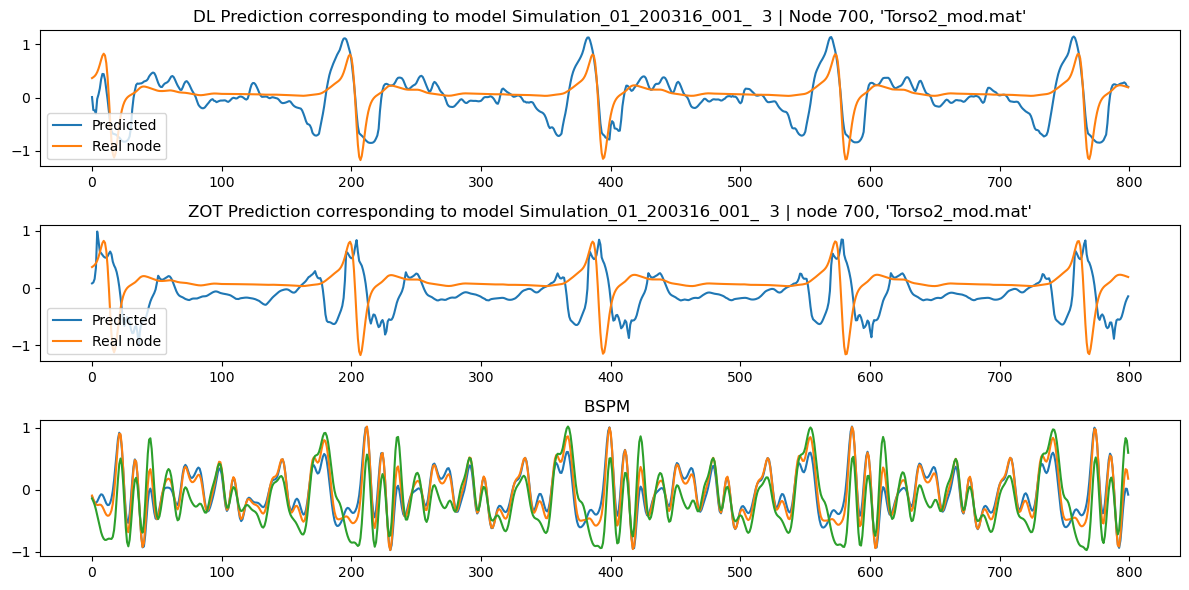

In [83]:


node_num=700
plt.figure(figsize=(12,6), tight_layout=True)
plt.subplot(3, 1, 1)
plt.plot(prediction_centered[:, node_num], label='Predicted')
plt.plot(egm_centered[:, node_num], label='Real node')
title=f"DL Prediction corresponding to model {model_name[0]} | Node {node_num}, '{torso_name}'"
plt.title(title)
plt.legend()
plt.subplot(3, 1, 2)
plt.plot(tik_rec_centered[:, node_num], label='Predicted')
plt.plot(egm_centered[:, node_num], label='Real node')
title=f"ZOT Prediction corresponding to model {model_name[0]} | node {node_num}, '{torso_name}'"
plt.title(title)
plt.legend()
plt.subplot(3, 1, 3)

plt.plot(X_1channel_centered[:, 0:3], label='Predicted')
title=f"BSPM {model_name}, node {node_num}, {torso_name}"
plt.title('BSPM ')
plt.show()

In [74]:
#Welch 

def compute_welch_periodogram(signal, fs, nperseg_value, title):

    plt.figure(figsize=(10, 3), tight_layout=True)
    for height in range(0, signal.shape[1], 5):
        f, Pxx_den = scipy.signal.welch(
            signal[:, height],
            fs,
            nperseg=nperseg_value,
            noverlap=nperseg_value // 2,
            scaling="density",
            detrend="linear"
        )
        plt.plot(f, Pxx_den, linewidth=0.5)
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("PSD [V²/Hz]")
    plt.title(title)
    plt.show()

In [75]:
print(egm_centered.shape, X_1channel_centered.shape, prediction_centered.shape)

(800, 2048) (800, 384) (800, 2048)


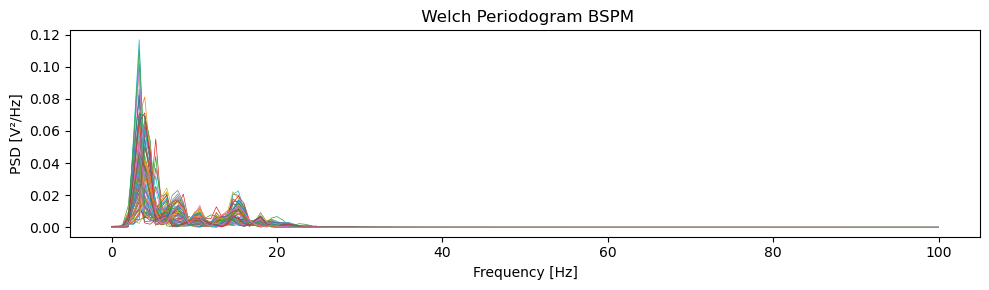

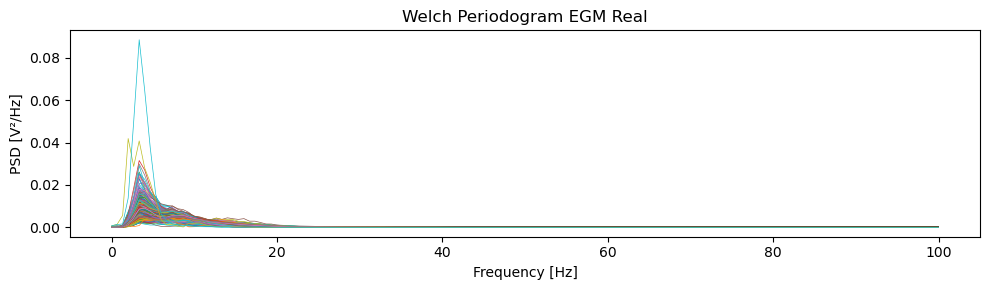

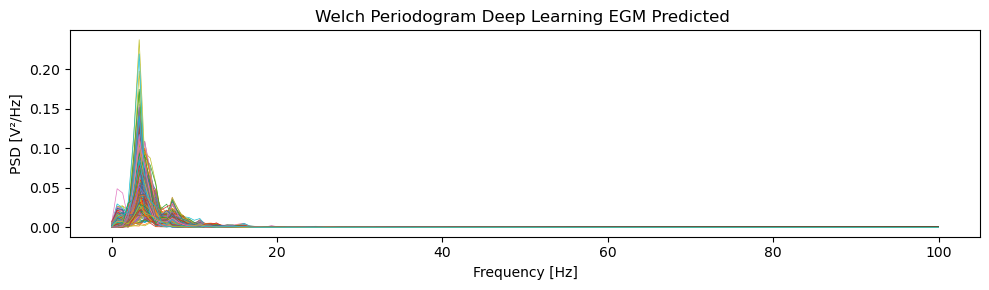

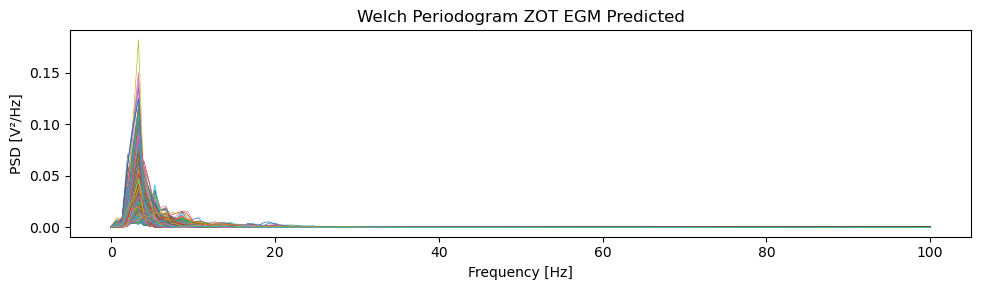

In [77]:
nperseg_value=300
compute_welch_periodogram(X_1channel_centered, fs=200, nperseg_value=nperseg_value, title=f" Welch Periodogram BSPM")
compute_welch_periodogram(egm_centered, fs=200, nperseg_value=nperseg_value, title=f"Welch Periodogram EGM Real")
compute_welch_periodogram(prediction_centered, fs=200, nperseg_value=nperseg_value, title=f"Welch Periodogram Deep Learning EGM Predicted ")
compute_welch_periodogram(tik_rec_centered, fs=200, nperseg_value=nperseg_value, title=f"Welch Periodogram ZOT EGM Predicted")